# Import CONFIG

In [1]:
import os
from pathlib import Path

project_root = Path(os.getcwd()).parent.resolve()
Path(project_root).resolve()
os.chdir(project_root)

In [2]:
import pandas as pd
from ieee_cis_fraud_detection import config


2026-02-23 22:34:53.817 | INFO     | ieee_cis_fraud_detection.config:<module>:11 - PROJ_ROOT path is: /home/laenra/projects/ieee-cis-fraud-detection


# Read Data

In [3]:
train_transaction_files= [
    os.path.join(
        config.INTERIM_DATA_DIR,
        'train_transaction_chunks',
        fn
    )
    for fn in os.listdir(os.path.join(config.INTERIM_DATA_DIR, 'train_transaction_chunks'))
]

identity_files= [
    os.path.join(
        config.INTERIM_DATA_DIR,
        'train_identity_chunks',
        fn
    )
    for fn in os.listdir(os.path.join(config.INTERIM_DATA_DIR, 'train_identity_chunks'))
]

print(f"Total number of train_transaction files: {len(train_transaction_files)}")
print(f"Total number of identity files: {len(identity_files)}")

Total number of train_transaction files: 60
Total number of identity files: 15


In [4]:
import dask.dataframe as dd
import pandas as pd

train_transaction_df= dd.read_parquet(train_transaction_files)
train_identity_df= dd.read_parquet(identity_files)

In [5]:
train_transaction_size= train_transaction_df.count().compute()
train_identity_size= train_identity_df.count().compute()

In [6]:
transaction_sample= train_transaction_df.get_partition(0).compute()

In [7]:
transaction_sample

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2996995,0,313063,40.00,H,13052,254.0,150.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9996,2996996,0,313068,57.00,W,11137,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9997,2996997,0,313099,108.95,W,15627,239.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9998,2996998,0,313110,160.95,W,7207,111.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Target balance

In [8]:
train_transaction_df.groupby(
    'isFraud'
).count().compute()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
isFraud,,,,,,,,,,,,,,,,,,,,,
1,20663,20663,20663,20663,20663,20240,20624,20622,20453,20624,...,3686,3686,3686,3686,3686,3686,3686,3686,3686,3686
0,569877,569877,569877,569877,569877,561367,568351,568341,565828,568345,...,78665,78665,78665,78665,78665,78665,78665,78665,78665,78665


In [9]:
fraud_by_card= train_transaction_df.groupby(
    ['card4','isFraud']
).agg(
    {
        'TransactionID': 'count'
    }
).compute().sort_index()

In [10]:
fraud_by_card

TransactionID
card4            isFraud               
american express 0                 8089
                 1                  239
discover         0                 6137
                 1                  514
mastercard       0               182721
                 1                 6496
visa             0               371394
                 1                13373

# Stats on samples

In [11]:
sampled_transactions= train_transaction_df.sample(frac= 0.3, random_state= 42).compute()

In [12]:
unique_transaction_id= sampled_transactions['TransactionID'].unique()
unique_transaction_id

array([2988703, 2991423, 2990610, ..., 3577182, 3577165, 3577435],
      shape=(177162,))

In [13]:
sampled_identities= train_identity_df.loc[
    train_identity_df['TransactionID'].isin(unique_transaction_id)
].compute()

In [14]:
sampled_identities

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,<NA>,<NA>,F,F,T,T,desktop,Windows
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS
5,2987017,-5.0,61141.0,3.0,0.0,3.0,0.0,NaN,NaN,3.0,...,chrome 62.0,24.0,1366x768,match_status:2,T,F,T,T,desktop,Windows
6,2987022,-15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
8,2987040,-10.0,116098.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,<NA>,<NA>,F,F,T,T,desktop,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144226,3577506,0.0,82599.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,ie 11.0 for desktop,24.0,1600x900,match_status:2,T,T,T,T,desktop,Trident/7.0
144227,3577509,-5.0,253305.0,0.0,0.0,0.0,-30.0,NaN,NaN,0.0,...,chrome 66.0 for android,NaN,<NA>,<NA>,F,F,T,F,mobile,SM-G930F Build/NRD90M
144229,3577526,-5.0,172059.0,NaN,NaN,1.0,-5.0,NaN,NaN,NaN,...,chrome 55.0 for android,32.0,855x480,match_status:2,T,F,T,F,mobile,A574BL Build/NMF26F
144230,3577529,-20.0,632381.0,NaN,NaN,-1.0,-36.0,NaN,NaN,NaN,...,chrome 65.0 for android,NaN,<NA>,<NA>,F,F,T,F,mobile,Moto E (4) Plus Build/NMA26.42-152


In [43]:
IDENTITY_COLUMNS= [
    'TransactionID',
    'TransactionDT',
    'ProductCD',
]

TARGET_COLUMN= 'isFraud'

CATEGORICAL_COLUMNS= sampled_transactions.select_dtypes(include= 'string[pyarrow]').columns.tolist()
NUMERICAL_COLUMNS= [
    col for col in sampled_transactions.select_dtypes(include= 'number').columns.tolist()
    if col not in IDENTITY_COLUMNS + [TARGET_COLUMN]
]

In [44]:
NUMERICAL_COLUMNS

['TransactionAmt',
 'card1',
 'card2',
 'card3',
 'card5',
 'addr1',
 'addr2',
 'dist1',
 'dist2',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'D8',
 'D9',
 'D10',
 'D11',
 'D12',
 'D13',
 'D14',
 'D15',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V65',
 'V66',
 'V67',
 'V68',
 'V69',
 'V70',
 'V71',
 'V72',
 'V73',
 'V74',
 'V75',
 'V76',
 'V77',
 'V78',
 'V79',
 'V80',
 'V81',
 'V82',
 'V83',
 'V84',
 'V85',
 'V86',
 'V87',


**Numerical corr**

In [ ]:
pearson_corr= sampled_transactions.select_dtypes(include='float').corr(method= 'pearson')
spearman_corr= sampled_transactions.select_dtypes(include='float').corr(method= 'spearman')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sbn

<Axes: xlabel='V331', ylabel='V332'>

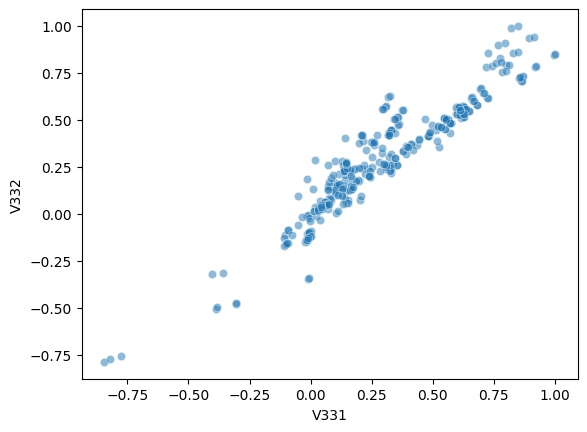

In [ ]:
sbn.scatterplot(
    data= spearman_corr,
    x= 'V331',
    y= 'V332',
    # hue= 'isFraud',
    alpha= 0.5
)

**Initial train to get feature importances**

In [ ]:
import numpy as np
sampled_transactions= sampled_transactions.replace(
    {pd.NaT: np.nan}
)

In [ ]:
import catboost as cb

In [ ]:
model= cb.CatBoostClassifier(
    iterations= 100,
    learning_rate= 0.1,
    depth= 6,
    eval_metric= 'AUC',
    loss_function= 'Logloss',
    random_seed= 42,
    verbose= 10,
    # cat_features= CATEGORICAL_COLUMNS
)

In [ ]:
model.fit(
    sampled_transactions.loc[:, NUMERICAL_COLUMNS],
    sampled_transactions[TARGET_COLUMN]
)

0:	total: 101ms	remaining: 10s
10:	total: 584ms	remaining: 4.73s
20:	total: 1.16s	remaining: 4.36s
30:	total: 1.67s	remaining: 3.71s
40:	total: 2.12s	remaining: 3.06s
50:	total: 2.55s	remaining: 2.45s
60:	total: 2.93s	remaining: 1.87s
70:	total: 3.29s	remaining: 1.34s
80:	total: 3.72s	remaining: 874ms
90:	total: 4.22s	remaining: 418ms
99:	total: 4.66s	remaining: 0us


In [ ]:
model.predict(sampled_transactions.loc[:, NUMERICAL_COLUMNS],prediction_type= 'RawFormulaVal')

array([-12.90539017, -11.37574154, -12.52125304, ..., -12.71309887,
       -12.90536718,  -9.30938673], shape=(177162,))

In [ ]:
try:
    os.mkdir(
        os.path.join(
            config.MODELS_DIR,
            'eda_catboost_model'
        )
    )
except:
    pass

In [ ]:
model.save_model(
    os.path.join(
        config.MODELS_DIR,
        'eda_catboost_model',
        'model.cbm'
    )
)

In [ ]:
model.feature_names_

['isFraud',
 'TransactionAmt',
 'card1',
 'card2',
 'card3',
 'card5',
 'addr1',
 'addr2',
 'dist1',
 'dist2',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'D8',
 'D9',
 'D10',
 'D11',
 'D12',
 'D13',
 'D14',
 'D15',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V65',
 'V66',
 'V67',
 'V68',
 'V69',
 'V70',
 'V71',
 'V72',
 'V73',
 'V74',
 'V75',
 'V76',
 'V77',
 'V78',
 'V79',
 'V80',
 'V81',
 'V82',
 'V83',
 'V84',
 'V85',
 'V8

In [ ]:
feature_importances_df= pd.DataFrame(
    data= model.feature_importances_,
    columns= ['feature_importance']
)
feature_importances_df['feature_name'] = model.feature_names_

In [ ]:
feature_importances_df.sort_values(
    by= 'feature_importance',
    ascending= False,
    inplace= True
    )

feature_importances_df['feature_importance_rank']= feature_importances_df['feature_importance'].rank(
    method= 'first',
    ascending= False
)

feature_importances_df['cumulative_importances']= feature_importances_df['feature_importance'].cumsum()

<Axes: xlabel='feature_importance_rank', ylabel='cumulative_importances'>

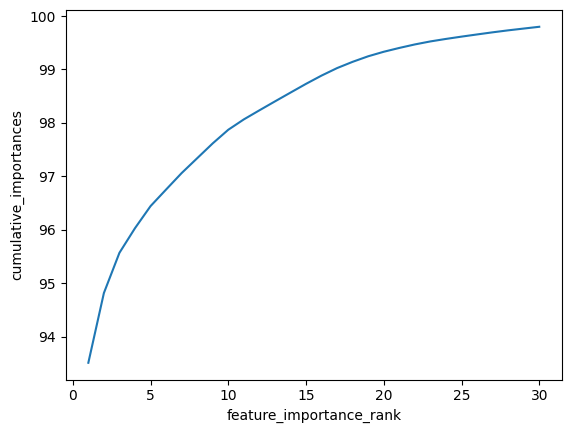

In [ ]:
import seaborn as sbn
import matplotlib.pyplot as plt

fig, ax= plt.subplots()
sbn.lineplot(
    data= feature_importances_df.head(30),
    x= 'feature_importance_rank',
    y= 'cumulative_importances',
    ax= ax
)

In [40]:
feature_importances_df.to_csv(
    os.path.join(
        config.INTERIM_DATA_DIR,
        'eda_catboost_feature_importances.csv'
    ),
    index= False
)

In [41]:
top_features= feature_importances_df.head(30)['feature_name'].tolist()

['isFraud',
 'V135',
 'V98',
 'V215',
 'V328',
 'V251',
 'V143',
 'V325',
 'V128',
 'card5',
 'V148',
 'V332',
 'V70',
 'V55',
 'V146',
 'V276',
 'V137',
 'V140',
 'V43',
 'V158',
 'V154',
 'V214',
 'V153',
 'V165',
 'V216',
 'V337',
 'V139',
 'V223',
 'V119',
 'V278']